In [1]:
import json
import networkx as nx

def load_graph(json_path: str) -> nx.DiGraph:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    G = nx.DiGraph()

    for func_id, meta in data.items():
        # add node (optional but useful for metadata queries)

        G.add_node(func_id, **meta)
            # add edges: caller -> callee

        for callee in meta["calls"]:
            G.add_edge(func_id, callee)

    return G

def find_node_by_name(G: nx.DiGraph, function_name: str):
    """
    Returns all nodes matching a function name (since names are not unique)
    """
    return [
        n for n, attr in G.nodes(data=True)
        if attr.get("name") == function_name
    ]


In [31]:

json_path = "output.json"
function_name = "cytoscape_workflow_by_category"

# load graph
G=load_graph(json_path)

node_name=find_node_by_name(G, function_name)
node_name=node_name[0] # if there are multiple, just take the first one for now

callers = list(G.predecessors(node_name))
for caller in callers:
    print(caller)
print("\n---\n")
# get successors (callees)
callees = list(G.successors(node_name))
for callee in callees:
    print(callee)


---

data_loader.py::load_data
data_loader.py::filter_by_category
graph_builder.py::build_graph
network_stats.py::print_statistics
cytoscape_visualizer.py::run_cytoscape_visualization


In [ ]:
# If you want everything that eventually leads into it:
all_callers = nx.ancestors(G,node_name)
for caller in all_callers:
    print(caller)

pyvis_main.py::workflow_largest_component
pyvis_main.py::workflow_by_category
pyvis_main.py::main
cytoscape_main.py::cytoscape_workflow_largest_component
cytoscape_main.py::cytoscape_workflow_by_tag
cytoscape_main.py::cytoscape_workflow_by_titles
cytoscape_main.py::main
pyvis_main.py::workflow_by_titles
pyvis_main.py::workflow_by_tag
cytoscape_main.py::cytoscape_workflow_by_category


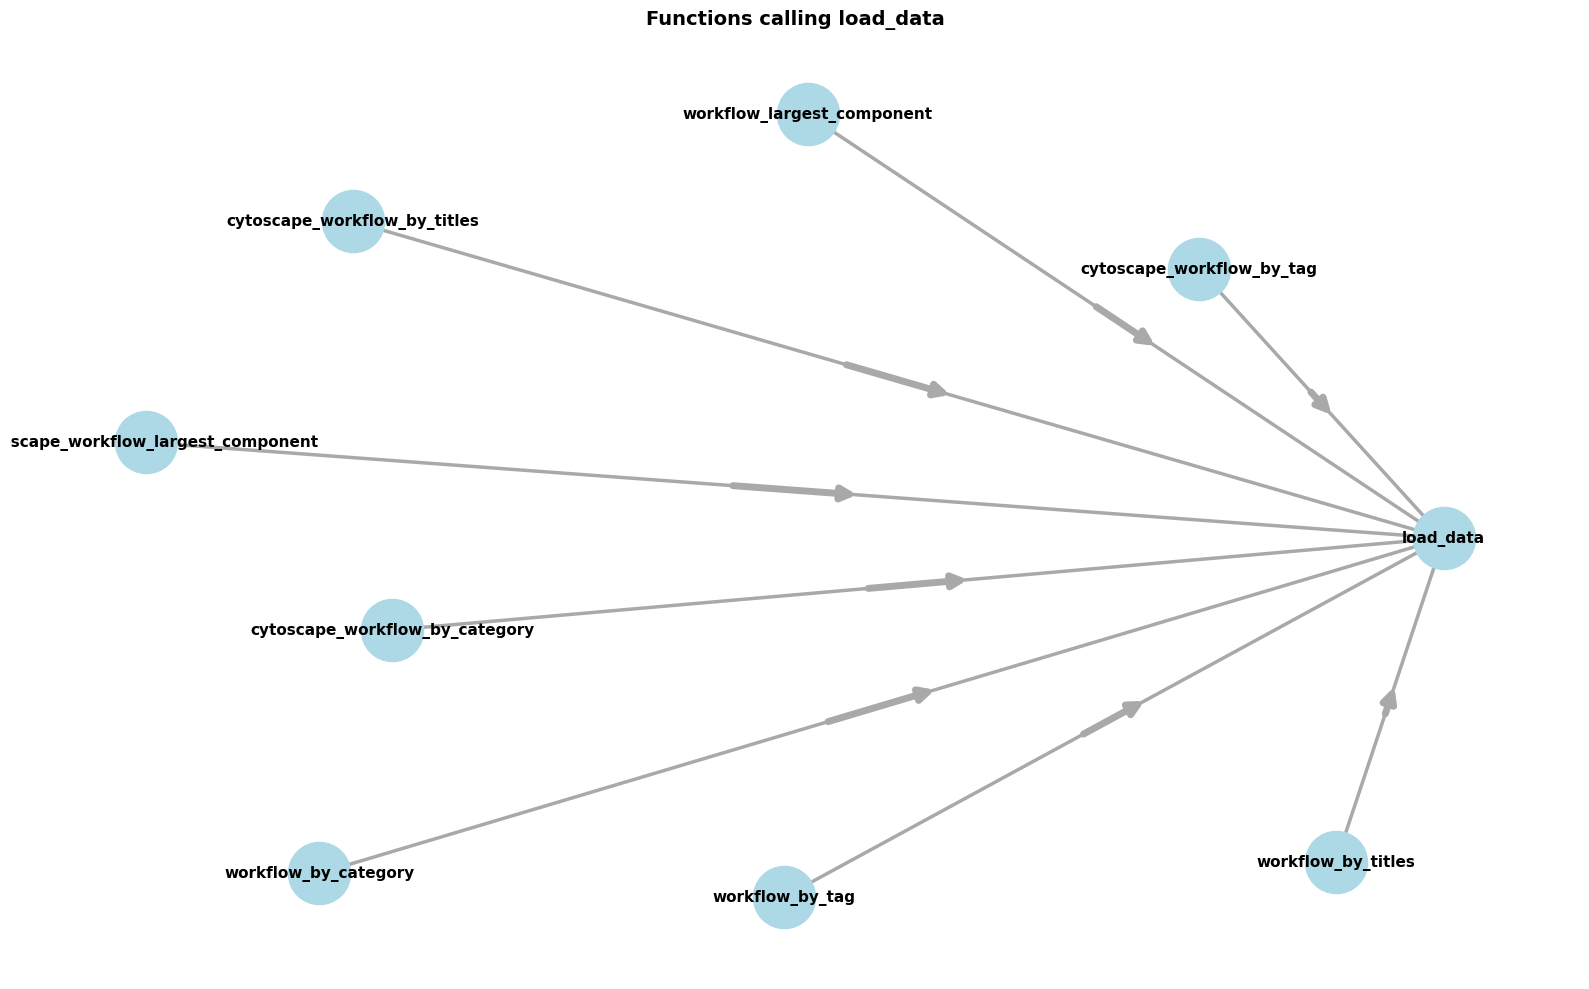

In [29]:
def visualize_callers_subgraph(G, node_name, include_all_ancestors=False, figsize=(16, 10)):
    """
    Visualize a subgraph showing functions that call a given function.
    
    Parameters:
    -----------
    G : nx.DiGraph
        The function call graph
    node_name : str
        The full node ID (from find_node_by_name)
    include_all_ancestors : bool
        If True, include all recursive callers. If False, only direct predecessors.
    figsize : tuple
        Figure size for the plot
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch
    
    if include_all_ancestors:
        # Get ALL ancestors (everything that eventually calls into this function)
        all_callers = nx.ancestors(G, node_name)
        nodes_to_show = [node_name] + list(all_callers)
    else:
        # Get only direct predecessors
        callers = list(G.predecessors(node_name))
        nodes_to_show = [node_name] + callers
    
    # Create subgraph
    subgraph = G.subgraph(nodes_to_show)
    
    # Draw it with better spacing and arrow visibility
    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    pos = nx.spring_layout(subgraph, seed=42, k=1, iterations=50)  # k=2 spreads nodes further apart
    
    # Draw nodes
    nx.draw_networkx_nodes(subgraph, pos, node_color='lightblue', node_size=2000, ax=ax)
    
    # Draw edges without arrows first
    nx.draw_networkx_edges(
        subgraph, pos, 
        edge_color='darkgray', 
        arrows=False,
        width=2.5,
        # connectionstyle='arc3,rad=0.1',
        ax=ax
    )
    
    # Draw arrows at midpoint of each edge
    for edge in subgraph.edges():
        start, end = edge
        x_start, y_start = pos[start]
        x_end, y_end = pos[end]
        
        # Calculate midpoint
        x_mid = (x_start + x_end) / 2
        y_mid = (y_start + y_end) / 2
        
        # Direction vector
        dx = x_end - x_start
        dy = y_end - y_start
        
        # Draw arrow at midpoint
        arrow = FancyArrowPatch(
            (x_mid - dx*0.05, y_mid - dy*0.05),
            (x_mid + dx*0.05, y_mid + dy*0.05),
            arrowstyle='-|>',
            color='darkgray',
            mutation_scale=20,
            linewidth=5,
            zorder=10
        )
        ax.add_patch(arrow)
    
    # Label nodes with function names (shorter than full IDs)
    labels = {node: G.nodes[node]['name'] for node in subgraph.nodes()}
    nx.draw_networkx_labels(subgraph, pos, labels, font_size=11, font_weight='bold', ax=ax)
    
    func_name = G.nodes[node_name]['name']
    ax.set_title(f"Functions calling {func_name}", fontsize=14, fontweight='bold')
    ax.axis('off')
    fig.tight_layout()
    plt.show()

# Usage:
visualize_callers_subgraph(G, node_name, include_all_ancestors=False)

In [ ]:
cytoscape_main.py::cytoscape_workflow_by_tag
cytoscape_main.py::cytoscape_workflow_by_titles
cytoscape_main.py::cytoscape_workflow_largest_component
cytoscape_main.py::cytoscape_workflow_by_category
pyvis_main.py::workflow_by_tag
pyvis_main.py::workflow_by_titles
pyvis_main.py::workflow_largest_component
pyvis_main.py::workflow_by_category